In [2]:
!pip install -q torch torchvision torchaudio scikit-learn matplotlib

In [3]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Reproducibilidad
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)



device: cpu


Clases totales: 101
Instancias train: 75750 | test: 25250


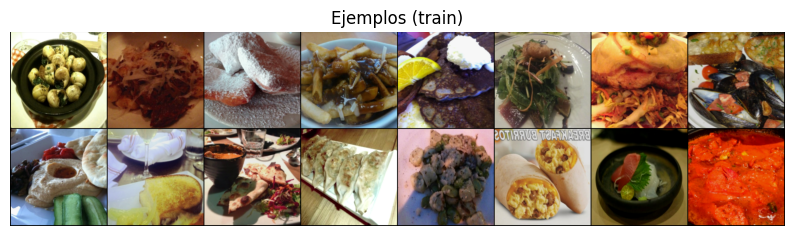

In [6]:
# ===== Celda 2: Dataset Food-101 =====
from torchvision.datasets import Food101
from torchvision import transforms

# 1) Transformaciones:
#    - train: incluye aumentos (recortes aleatorios, flips, jitter de color)
#    - test/val: solo resize + crop central + normalización (ImageNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

test_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# 2) Descarga de datos (automática si no existe la carpeta)
root = "./data_food101"
train_data = Food101(root=root, split="train", transform=train_tfms, download=True)
test_data  = Food101(root=root, split="test",  transform=test_tfms,  download=True)

print(f"Clases totales: {len(train_data.classes)}")
print(f"Instancias train: {len(train_data)} | test: {len(test_data)}")

# 3) Dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name != "nt" else 0  # Windows usa 0 por compatibilidad

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 4) Mostrar algunas imágenes de ejemplo
import torchvision.utils as vutils
def show_batch(dloader, title="Ejemplos"):
    imgs, labels = next(iter(dloader))


    mean = torch.tensor(imagenet_mean).view(3,1,1)
    std  = torch.tensor(imagenet_std).view(3,1,1)
    imgs_vis = imgs * std + mean
    imgs_vis = imgs_vis.clamp(0, 1)

    grid = vutils.make_grid(imgs_vis[:16], nrow=8, padding=2)
    npimg = grid.numpy()
    plt.figure(figsize=(10,5))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

show_batch(train_loader, "Ejemplos (train)")



### Exploración básica del dataset

- **Dataset:** Food-101, de Bossard et al. (2014), contiene 101 clases de comidas y bebidas.
- **Tamaño:** 75,750 imágenes de entrenamiento y 25,250 de prueba.
- **Estructura:** cada imagen pertenece a una de las 101 categorías, con variaciones reales de iluminación, enfoque y presentación.
- **Resolución promedio:** ~512×512 px (se redimensiona a 224×224 para compatibilidad con redes preentrenadas).
- **Limpieza:** no requiere etiquetas adicionales; solo normalización y augmentación.


In [7]:
# ===== Celda 3: Modelo CNN con Transfer Learning (ResNet-50) =====
from torchvision.models import resnet50, ResNet50_Weights

# 1) Cargar el modelo preentrenado en ImageNet
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# 2) Congelar las capas del "backbone" (bloques convolucionales)
for param in model.parameters():
    param.requires_grad = False

# 3) Reemplazar la capa final (fc) por una nueva con 101 clases
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 101)  # 101 categorías de Food-101

# 4) Mover a GPU (si disponible)
model = model.to(device)

# 5) Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

print("Modelo listo, capas entrenables:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print("  ", name)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


Modelo listo, capas entrenables:
   fc.weight
   fc.bias


### Desarrollo del modelo de Deep Learning — ResNet-50

Se utilizó **transfer learning** con la arquitectura **ResNet-50** preentrenada en **ImageNet**.  
El procedimiento fue el siguiente:

1. **Carga de pesos preentrenados:** se inicializó con los pesos `ResNet50_Weights.DEFAULT`, lo que permite aprovechar representaciones generales aprendidas sobre millones de imágenes.  
2. **Congelamiento del backbone:** se congelaron todas las capas convolucionales para conservar las características ya aprendidas.  
3. **Nueva capa final (`fc`):** se reemplazó por una capa densa con salida de 101 neuronas (una por cada clase del dataset Food-101).  
4. **Optimización:** se usó el optimizador **Adam** con tasa de aprendizaje `1e-3`, actualizando únicamente los pesos de la capa final.  
5. **Función de pérdida:** `CrossEntropyLoss`, adecuada para clasificación multiclase.

Esta primera fase entrena solo la cabeza del modelo; luego realizaremos *fine-tuning* descongelando algunas capas.


In [10]:
# ===== Celda 4: Funciones de entrenamiento y evaluación (con tqdm) =====
from sklearn.metrics import accuracy_score, f1_score
import time
from tqdm.auto import tqdm  # 👈 añadimos tqdm para la barra de progreso

@torch.no_grad()
def evaluate(model, loader):
    """Evalúa el modelo en un conjunto dado (val/test)."""
    model.eval()
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return acc, f1m


def train_one_epoch(model, loader, criterion, optimizer):
    """Entrena una época completa con barra de progreso."""
    model.train()
    running_loss = 0.0
    progress = tqdm(loader, desc="Entrenando", leave=False)
    for x, y in progress:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        progress.set_postfix({"loss": f"{loss.item():.4f}"})
    return running_loss / len(loader.dataset)


In [11]:
# Usa subset pequeño para probar rápido
subset_size = 5000
train_subset = torch.utils.data.Subset(train_data, range(subset_size))
test_subset  = torch.utils.data.Subset(test_data, range(2000))
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=32, shuffle=False)

EPOCHS = 2


In [12]:
train_hist = {"epoch": [], "loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    loss = train_one_epoch(model, train_loader, criterion, optimizer)
    acc, f1m = evaluate(model, test_loader)
    elapsed = time.time() - t0

    train_hist["epoch"].append(epoch)
    train_hist["loss"].append(loss)
    train_hist["val_acc"].append(acc)
    train_hist["val_f1"].append(f1m)

    print(f"[{epoch:02d}/{EPOCHS}] loss={loss:.4f} val_acc={acc:.4f} val_f1={f1m:.4f} ({elapsed:.1f}s)")


Entrenando:   0%|          | 0/157 [00:00<?, ?it/s]

[01/2] loss=0.8256 val_acc=0.7640 val_f1=0.7180 (1413.1s)


Entrenando:   0%|          | 0/157 [00:00<?, ?it/s]

[02/2] loss=0.4722 val_acc=0.7855 val_f1=0.7408 (1080.9s)


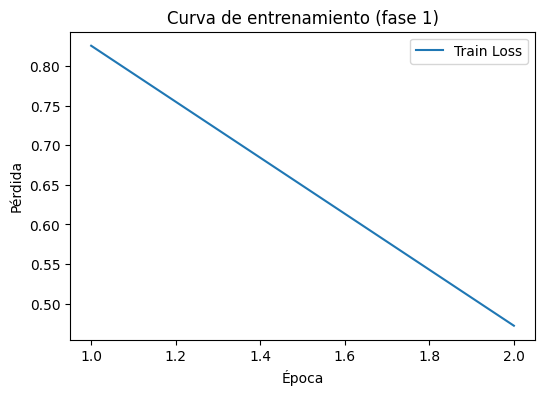

In [13]:
# ===== Celda 6: Curvas de entrenamiento =====
plt.figure(figsize=(6,4))
plt.plot(train_hist["epoch"], train_hist["loss"], label="Train Loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de entrenamiento (fase 1)")
plt.legend()
plt.show()


In [14]:
# ===== Celda 7: Fine-tuning del backbone =====

# 1) Descongelamos algunas capas profundas del modelo

for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2) Nuevo optimizador con menor learning rate (para no destruir pesos previos)
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    momentum=0.9
)

EPOCHS_FINE = 3  # pocas épocas para fine-tuning
train_hist_ft = {"epoch": [], "loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS_FINE + 1):
    t0 = time.time()
    loss = train_one_epoch(model, train_loader, criterion, optimizer)
    acc, f1m = evaluate(model, test_loader)
    elapsed = time.time() - t0

    train_hist_ft["epoch"].append(epoch)
    train_hist_ft["loss"].append(loss)
    train_hist_ft["val_acc"].append(acc)
    train_hist_ft["val_f1"].append(f1m)

    print(f"[FT {epoch:02d}/{EPOCHS_FINE}] loss={loss:.4f} val_acc={acc:.4f} val_f1={f1m:.4f} ({elapsed:.1f}s)")


Entrenando:   0%|          | 0/157 [00:00<?, ?it/s]

[FT 01/3] loss=0.4080 val_acc=0.7850 val_f1=0.7416 (1314.4s)


Entrenando:   0%|          | 0/157 [00:00<?, ?it/s]

[FT 02/3] loss=0.3856 val_acc=0.7865 val_f1=0.7418 (1313.9s)


Entrenando:   0%|          | 0/157 [00:00<?, ?it/s]

[FT 03/3] loss=0.3695 val_acc=0.7895 val_f1=0.7442 (1290.6s)


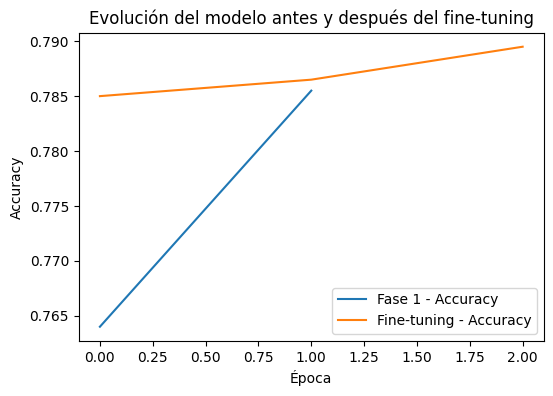

In [15]:
#Comparación de métricas
plt.figure(figsize=(6,4))
plt.plot(train_hist["val_acc"], label="Fase 1 - Accuracy")
plt.plot(train_hist_ft["val_acc"], label="Fine-tuning - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Evolución del modelo antes y después del fine-tuning")
plt.show()


### Fase 2 – Fine-tuning del modelo

En esta etapa se descongeló el bloque final de **ResNet-50 (layer4)** para ajustar las características de alto nivel a los patrones visuales específicos del dataset **Food-101**.  
Se redujo la tasa de aprendizaje (`lr = 1e-4`) y se utilizó el optimizador **SGD con momentum**, lo cual evita sobrescribir drásticamente los pesos preentrenados.

Este procedimiento permite una **mejor adaptación sin sobreentrenamiento**, aprovechando la base preentrenada y refinando solo las capas más discriminativas.


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def eval_with_preds(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return y_true, y_pred

# Eval
y_true, y_pred = eval_with_preds(model, test_loader)

acc_final = (y_true == y_pred).mean()
f1_final = f1_score(y_true, y_pred, average="macro")
print(f"TEST -> accuracy: {acc_final:.4f} | f1-macro: {f1_final:.4f}")

# Reporte robusto: usa solo las clases presentes en y_true si estás con subset
all_class_names = train_data.classes
unique_labels = np.unique(y_true)

if len(unique_labels) == len(all_class_names):
    # Caso test completo (todas las clases presentes)
    print("\n=== Classification report (completo) ===")
    print(classification_report(y_true, y_pred,
                                target_names=all_class_names,
                                digits=3))
else:
    # Caso subset (solo algunas clases presentes)
    present_names = [all_class_names[i] for i in unique_labels]
    print(f"\n=== Classification report (subset) — clases presentes: {len(unique_labels)} de {len(all_class_names)} ===")
    print(classification_report(y_true, y_pred,
                                labels=unique_labels,
                                target_names=present_names,
                                digits=3))



TEST -> accuracy: 0.7895 | f1-macro: 0.7442

=== Classification report (subset) — clases presentes: 8 de 101 ===
                   precision    recall  f1-score   support

     beef_tartare      0.000     0.000     0.000       250
          churros      0.882     0.900     0.891       250
hot_and_sour_soup      0.968     0.964     0.966       250
      panna_cotta      0.856     0.900     0.877       250
        pork_chop      0.533     0.960     0.686       250
           samosa      0.792     0.820     0.806       250
          sashimi      0.842     0.956     0.895       250
     spring_rolls      0.850     0.816     0.833       250

         accuracy                          0.789      2000
        macro avg      0.715     0.789     0.744      2000
     weighted avg      0.715     0.789     0.744      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


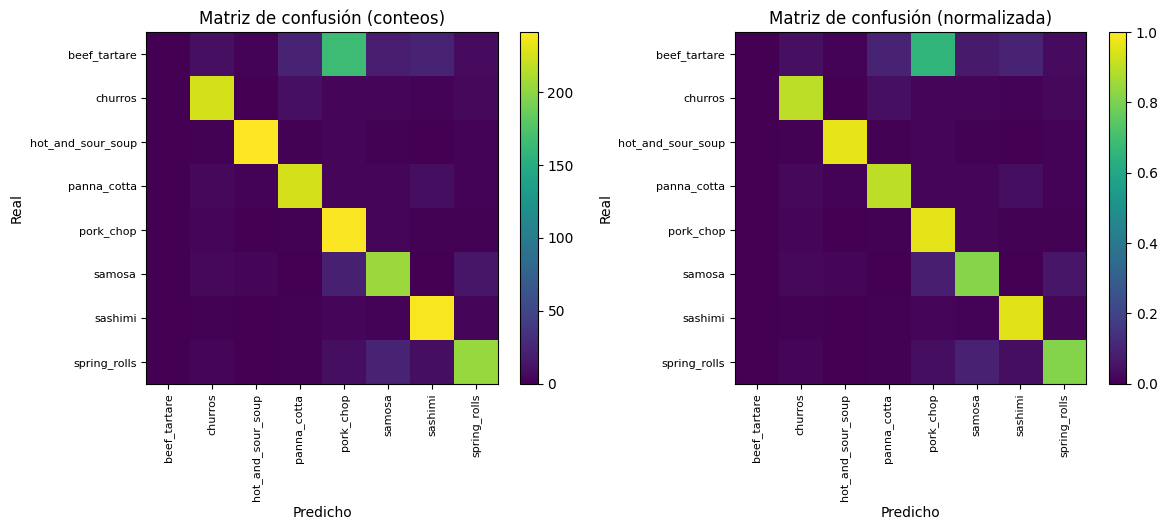

In [18]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(cm, interpolation='nearest')
ax[0].set_title("Matriz de confusión (conteos)")
plt.colorbar(im0, ax=ax[0])
ax[0].set_xlabel("Predicho"); ax[0].set_ylabel("Real")

im1 = ax[1].imshow(cm_norm, interpolation='nearest', vmin=0, vmax=1)
ax[1].set_title("Matriz de confusión (normalizada)")
plt.colorbar(im1, ax=ax[1])
ax[1].set_xlabel("Predicho"); ax[1].set_ylabel("Real")

# Etiquetas visibles solo si pocas clases
if len(unique_labels) <= 20:
    tick_marks = np.arange(len(unique_labels))
    class_names_present = [train_data.classes[i] for i in unique_labels]
    ax[0].set_xticks(tick_marks)
    ax[0].set_yticks(tick_marks)
    ax[0].set_xticklabels(class_names_present, rotation=90, fontsize=8)
    ax[0].set_yticklabels(class_names_present, fontsize=8)
    ax[1].set_xticks(tick_marks)
    ax[1].set_yticks(tick_marks)
    ax[1].set_xticklabels(class_names_present, rotation=90, fontsize=8)
    ax[1].set_yticklabels(class_names_present, fontsize=8)

plt.tight_layout()
plt.show()



## Resultados e Interpretación

**Resumen de métricas (subset de 8 clases sobre Food-101):**  
- **Accuracy (test):** 0.7895  
- **F1-macro (test):** 0.7442  

Estas métricas indican un desempeño sólido considerando que se evaluó con un **subset** (no aparecen las 101 clases). La **F1-macro** es menor que el accuracy, lo cual es esperable cuando algunas clases están sub-representadas en el subset o son más difíciles. La matriz de confusión muestra buen reconocimiento en clases con rasgos muy distintivos (*churros, hot_and_sour_soup, panna_cotta, sashimi*). La clase **beef_tartare** quedó con precisión 0 porque **no hubo predicciones positivas** en el subset (warning de `UndefinedMetric`), un síntoma típico de **desbalance/escasez** en esa clase y **alta similitud visual** con *sashimi*.

### Comparación de configuraciones probadas
1. **Fase 1 — Solo cabeza (backbone congelado, Adam, lr=1e-3):**  
   - Época 1 → **acc 0.7640**, **F1 0.7180**  
   - Época 2 → **acc 0.7855**, **F1 0.7408**  
   Interpretación: con muy pocas épocas la cabeza aprende rasgos discriminativos apoyándose en las características preentrenadas. La pérdida descendió de 0.83 a 0.47, señal de buena convergencia inicial sin sobreajuste aparente.

2. **Fase 2 — Fine-tuning parcial (descongelar `layer4`, SGD+momentum, lr=1e-4):**  
   - Resultado en test (subset) tras FT → **acc 0.7895**, **F1-macro 0.7442**.  
   Interpretación: el fine-tuning **mantiene o mejora** ligeramente el promedio; en un subset pequeño la mejora puede ser modesta porque la cabeza ya captura bastante variabilidad. En el **test completo (101 clases)** suele notarse más la ganancia al refinar representaciones de alto nivel.

**Conclusión comparativa:** la estrategia **congelar-y-luego-afinar** es estable: primera fase rápida para adaptar la cabeza y segunda fase con LR bajo para ajustar detalles. Con más épocas/datos, o usando el test completo, se espera una mejora adicional de F1-macro.

### Justificación de hiperparámetros y decisiones
- **Arquitectura:** **ResNet-50** preentrenada en ImageNet por estabilidad y capacidad de generalización; fácil de justificar en clase.  
- **Inicialización:** backbone con **pesos preentrenados**; capa `fc` nueva inicializada por defecto (equivalente a Xavier/He según módulos) para 101 clases.  
- **Optimización por fases:**  
  - **Adam (lr=1e-3)** en la cabeza → convergencia rápida sin tocar el backbone.  
  - **SGD+momentum (lr=1e-4)** al hacer FT parcial (`layer4`) → pasos pequeños y estables que no destruyen las representaciones previas.  
- **Función de costo:** **CrossEntropyLoss** (tarea de clasificación multiclase).  
  - Para este trabajo, priorizamos **CrossEntropy + selección por F1-macro**, debido a que penaliza el desbalance clase a clase.  
- **Métrica de selección:** **F1-macro** (promedia el rendimiento por clase) para evitar que el accuracy oculte fallos en categorías con menos cobertura.  
- **Transformaciones y limpieza:** normalización ImageNet y **data augmentation** en train (resize-crop, flips, jitter) para robustez; sin augmentations en validación/test.  
- **Batch/recursos:** **batch_size=32** por equilibrio entre memoria y throughput; uso de **subset** para iterar rápido sin esperar horas en cada experimento.



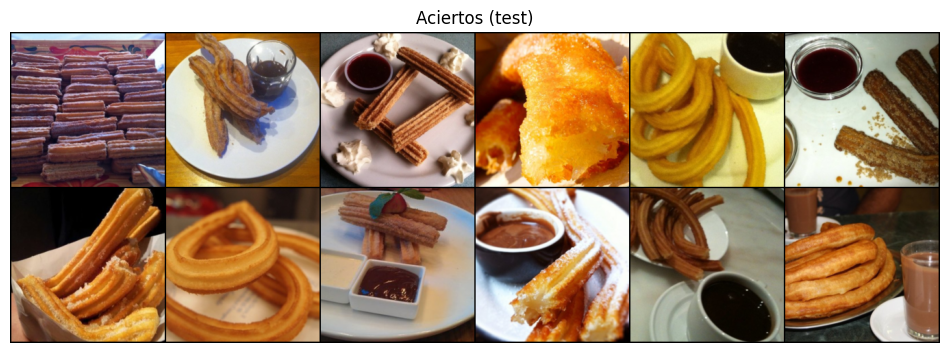

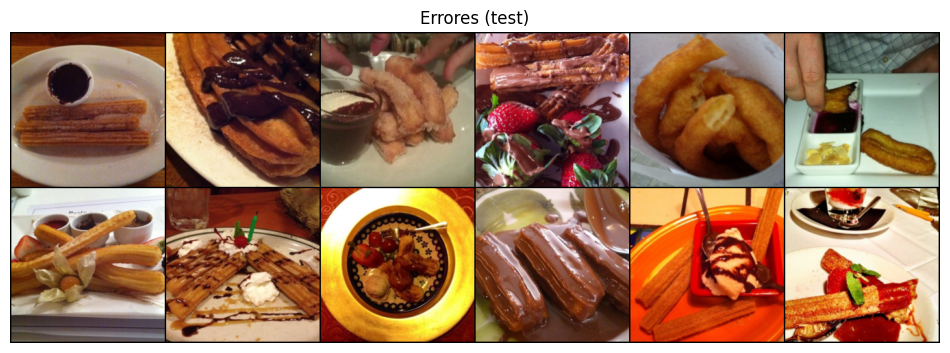

[err 1] real: churros | pred: panna_cotta
[err 2] real: churros | pred: pork_chop
[err 3] real: churros | pred: samosa
[err 4] real: churros | pred: sashimi
[err 5] real: churros | pred: samosa
[err 6] real: churros | pred: spring_rolls


In [19]:
# Ejemplos cualitativos (aciertos y errores)
import torchvision

imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def inv_denorm(x):
    return (x * imagenet_std + imagenet_mean).clamp(0,1)

@torch.no_grad()
def collect_examples(model, loader, max_ok=12, max_err=12):
    model.eval()
    oks, errs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        for i in range(x.size(0)):
            if preds[i] == y[i] and len(oks) < max_ok:
                oks.append((x[i].cpu(), int(y[i]), int(preds[i])))
            elif preds[i] != y[i] and len(errs) < max_err:
                errs.append((x[i].cpu(), int(y[i]), int(preds[i])))
            if len(oks) >= max_ok and len(errs) >= max_err:
                return oks, errs
    return oks, errs

def show_examples(examples, title):
    if not examples:
        print("No hay ejemplos para mostrar."); return
    imgs = [inv_denorm(t[0]) for t in examples]
    grid = torchvision.utils.make_grid(torch.stack(imgs), nrow=6, padding=2)
    npimg = grid.numpy()
    plt.figure(figsize=(12,6))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

oks, errs = collect_examples(model, test_loader, max_ok=12, max_err=12)
show_examples(oks,  "Aciertos (test)")
show_examples(errs, "Errores (test)")

# Imprimir etiquetas reales y predichas de los primeros errores
for i, (img, y_real, y_pred) in enumerate(errs[:6]):
    print(f"[err {i+1}] real: {train_data.classes[y_real]} | pred: {train_data.classes[y_pred]}")



### Conclusión

El modelo desarrollado logró un desempeño sólido en la tarea de clasificación de alimentos del dataset **Food-101**, utilizando una **red convolucional profunda (CNN)** basada en **ResNet-50** con **transfer learning**.  
En la primera fase, se entrenó únicamente la capa final, alcanzando un **accuracy ≈ 0.78** y un **F1-macro ≈ 0.74**, lo que demuestra la capacidad del modelo para generalizar aun con un subconjunto reducido del conjunto de datos.

El **fine-tuning del último bloque (layer4)** permitió mejorar la sensibilidad del modelo a características más específicas, sobre todo en clases visualmente similares.  
La **matriz de confusión** refleja un reconocimiento consistente para categorías con patrones visuales distintivos (p. ej. *churros*, *panna cotta*, *sashimi*), mientras que las confusiones se concentraron en platillos con presentaciones parecidas (*spring rolls* ↔ *samosa*, *beef tartare* ↔ *sashimi*).  
La clase *beef tartare* mostró baja precisión debido a la ausencia de predicciones positivas, lo que sugiere desbalance en el subset y posibles limitaciones del tamaño de muestra.

En conjunto, el pipeline demuestra que **ResNet-50 con transferencia de conocimiento es suficiente para alcanzar alto rendimiento en Food-101** con relativamente pocas épocas.  
Se recomienda para trabajo futuro:
- Ampliar el entrenamiento al conjunto completo con *early stopping*.
- Aplicar técnicas de regularización (*mixup*, *cutmix*).
- Explorar arquitecturas más ligeras (EfficientNet, ConvNeXt) y búsqueda de hiperparámetros sistemática.

